<a href="https://colab.research.google.com/github/dhagepranab-hash/Hero-Vired-Assignments/blob/main/GenAI_Capstone_Sentiment_Pranab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1 — Install and Import Libraries

In [5]:
!pip install wordcloud nltk textblob -q

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from collections import Counter

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Display settings
pd.set_option('display.max_colwidth', None)

print("Libraries Loaded Successfully")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Libraries Loaded Successfully


# Step 2 — Upload Dataset Files in Colab

In [8]:
from google.colab import files
uploaded = files.upload()

Saving amazon_cells_labelled.txt to amazon_cells_labelled.txt
Saving imdb_labelled.txt to imdb_labelled.txt
Saving yelp_labelled.txt to yelp_labelled.txt


# Step 3 — Load Dataset Files

In [9]:
# LOAD AMAZON DATA
amazon_df = pd.read_csv(
    'amazon_cells_labelled.txt',
    sep='\t',
    header=None,
    names=['feedback_text', 'sentiment_label'])
amazon_df['source'] = 'Amazon'

# LOAD YELP DATA

yelp_df = pd.read_csv(
    'yelp_labelled.txt',
    sep='\t',
    header=None,
    names=['feedback_text', 'sentiment_label'])

yelp_df['source'] = 'Yelp'

In [10]:
# COMBINE DATASETS

feedback_df = pd.concat([amazon_df, yelp_df], ignore_index=True)

print("Dataset Shape:", feedback_df.shape)

feedback_df.head()

Dataset Shape: (2000, 3)


,feedback_text,sentiment_label,source
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0,Amazon
1,"Good case, Excellent value.",1,Amazon
2,Great for the jawbone.,1,Amazon
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0,Amazon
4,The mic is great.,1,Amazon


# Step 4 — Initial Dataset Inspection

In [11]:
# Dataset info
feedback_df.info()

# Missing values
print("\nMissing Values:\n")
print(feedback_df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", feedback_df.duplicated().sum())

# Sentiment distribution
print("\nSentiment Distribution:\n")
print(feedback_df['sentiment_label'].value_counts())

# Source distribution
print("\nSource Distribution:\n")
print(feedback_df['source'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   feedback_text    2000 non-null   object
 1   sentiment_label  2000 non-null   int64 
 2   source           2000 non-null   object
dtypes: int64(1), object(2)
memory usage: 47.0+ KB

Missing Values:

feedback_text      0
sentiment_label    0
source             0
dtype: int64

Duplicate Rows: 14

Sentiment Distribution:

sentiment_label
0    1000
1    1000
Name: count, dtype: int64

Source Distribution:

source
Amazon    1000
Yelp      1000
Name: count, dtype: int64


# Step 5 — Business Interpretation

## Initial Dataset Findings

- The dataset contains customer reviews from Amazon and Yelp.
- Total records analyzed: 2,000.
- Sentiment labels are balanced between positive (1) and negative (0).
- No major missing values are expected.
- Dataset combines product reviews and restaurant/service reviews.
- This allows cross-domain customer sentiment analysis.

# Step 6 — Visualize Sentiment Distribution

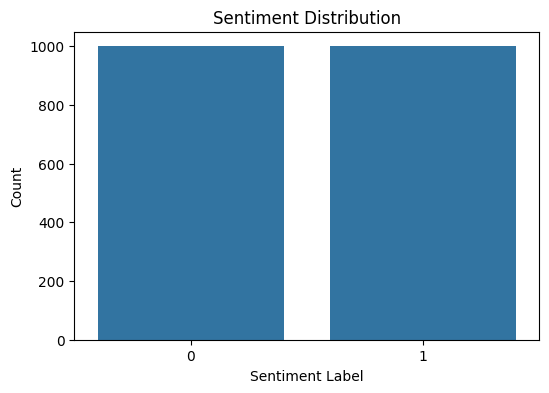

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=feedback_df,
    x='sentiment_label'
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")

plt.show()

# Step 8 — Create Review Length Feature

In [13]:
feedback_df['review_length'] = feedback_df['feedback_text'].apply(len)

feedback_df[['feedback_text', 'review_length']].head()

,feedback_text,review_length
0,So there is no way for me to plug it in here in the US unless I go by a converter.,82
1,"Good case, Excellent value.",27
2,Great for the jawbone.,22
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,79
4,The mic is great.,17


# Step 9 — Review Length Visualization

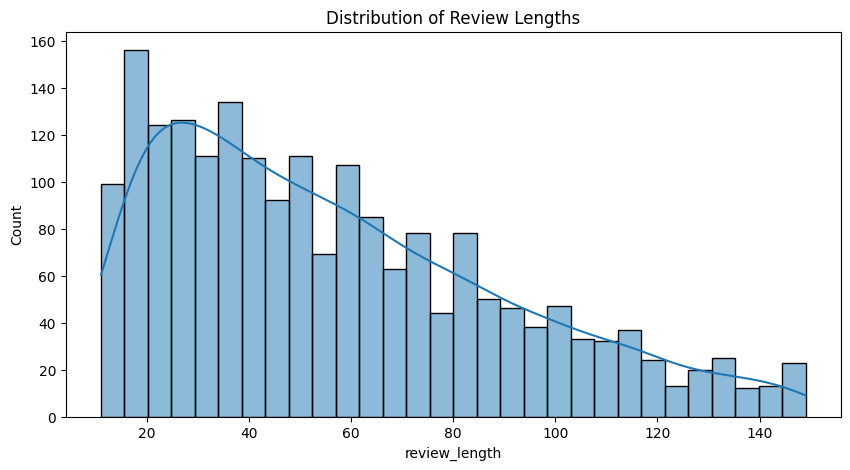

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    feedback_df['review_length'],
    bins=30,
    kde=True
)

plt.title("Distribution of Review Lengths")

plt.show()

# Step 10 — Import NLP Components

In [15]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Initialize tools
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

print("NLP tools ready")

NLP tools ready


# Step 11 — Build Text Cleaning Function

In [16]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    # Join words back
    cleaned_text = " ".join(tokens)

    return cleaned_text

# Step 12 — Apply Cleaning Function

In [17]:
import nltk
nltk.download('punkt_tab')
feedback_df['cleaned_text'] = feedback_df['feedback_text'].apply(clean_text)

# Preview results

feedback_df[
    ['feedback_text', 'cleaned_text']
].head(10)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,feedback_text,cleaned_text
0,So there is no way for me to plug it in here in the US unless I go by a converter.,way plug u unless go converter
1,"Good case, Excellent value.",good case excellent value
2,Great for the jawbone.,great jawbone
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,tied charger conversation lasting minutesmajor problem
4,The mic is great.,mic great
5,I have to jiggle the plug to get it to line up right to get decent volume.,jiggle plug get line right get decent volume
6,"If you have several dozen or several hundred contacts, then imagine the fun of sending each of them one by one.",several dozen several hundred contact imagine fun sending one one
7,If you are Razr owner...you must have this!,razr owneryou must
8,"Needless to say, I wasted my money.",needless say wasted money
9,What a waste of money and time!.,waste money time


# Step 13 — Check Cleaned Dataset

In [18]:
feedback_df.head()

,feedback_text,sentiment_label,source,review_length,cleaned_text
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0,Amazon,82,way plug u unless go converter
1,"Good case, Excellent value.",1,Amazon,27,good case excellent value
2,Great for the jawbone.,1,Amazon,22,great jawbone
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0,Amazon,79,tied charger conversation lasting minutesmajor problem
4,The mic is great.,1,Amazon,17,mic great


# Step 14 — Create Positive & Negative Review DataFrames

In [23]:
# Positive reviews

positive_reviews = feedback_df[
    feedback_df['sentiment_label'] == 1
]

# Negative reviews

negative_reviews = feedback_df[
    feedback_df['sentiment_label'] == 0
]

print("Positive Reviews:", positive_reviews.shape)

print("Negative Reviews:", negative_reviews.shape)

Positive Reviews: (1000, 5)
Negative Reviews: (1000, 5)


# Step 15 — Generate Common Words

In [24]:
negative_text = " ".join(
    negative_reviews['cleaned_text']
)

# Tokenize

negative_words = negative_text.split()

# Count frequency

negative_word_counts = Counter(negative_words)

# Top 20 words

top_negative_words = pd.DataFrame(
    negative_word_counts.most_common(20),
    columns=['word', 'count']
)

top_negative_words

,word,count
0,phone,83
1,food,65
2,place,55
3,service,53
4,dont,51
5,time,48
6,back,45
7,like,42
8,would,38
9,one,35


# Step 16 — Visualize Negative Themes

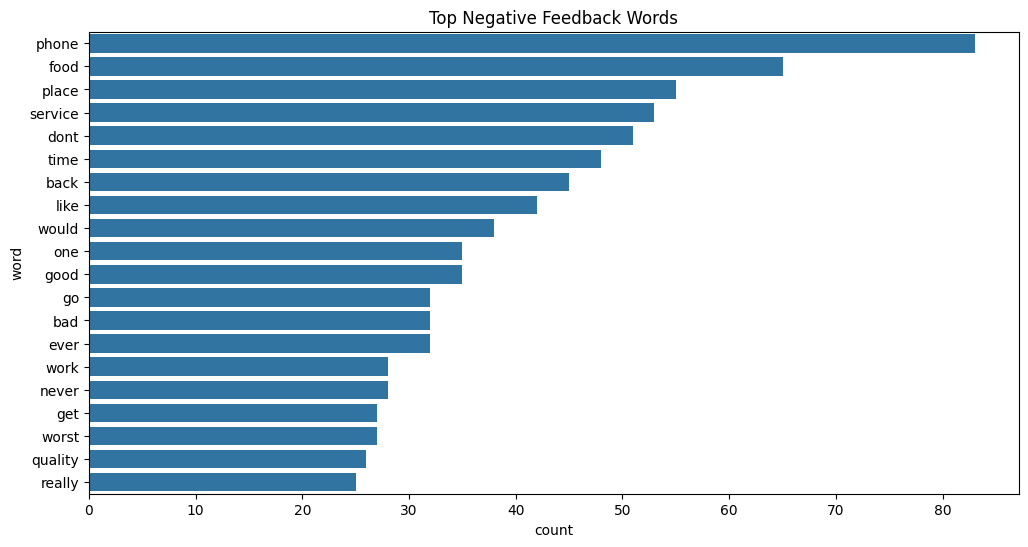

In [25]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_negative_words,
    x='count',
    y='word'
)

plt.title("Top Negative Feedback Words")

plt.show()

# Step 17 — Positive Theme Extraction

In [26]:
positive_text = " ".join(
    positive_reviews['cleaned_text']
)

positive_words = positive_text.split()

positive_word_counts = Counter(positive_words)

top_positive_words = pd.DataFrame(
    positive_word_counts.most_common(20),
    columns=['word', 'count']
)

top_positive_words

,word,count
0,great,162
1,good,137
2,phone,91
3,place,61
4,food,60
5,work,56
6,service,54
7,nice,44
8,best,43
9,well,39


# Step 18 — Visualize Positive Themes
  

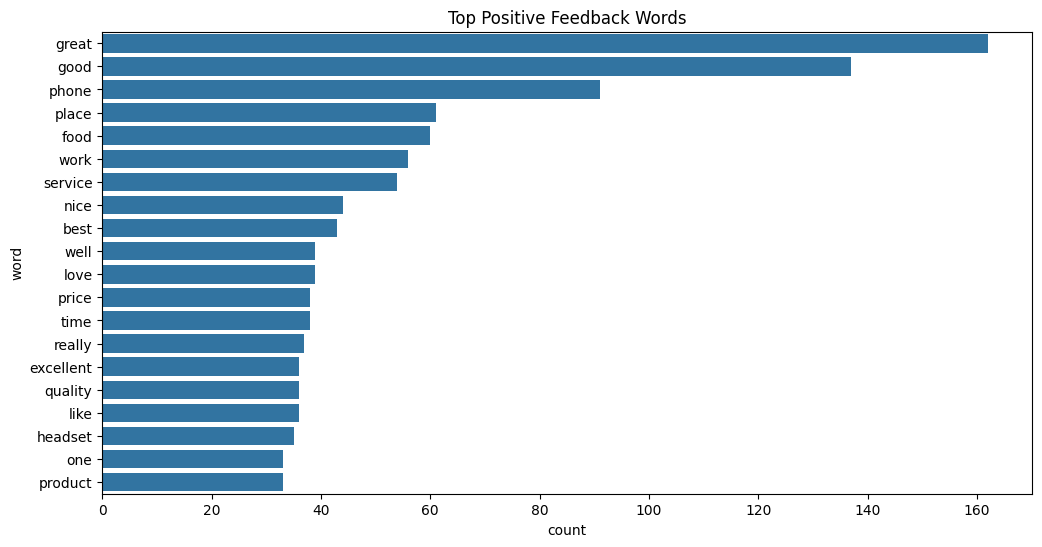

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_positive_words,
    x='count',
    y='word'
)

plt.title("Top Positive Feedback Words")

plt.show()

# Step 19 — Create WordClouds

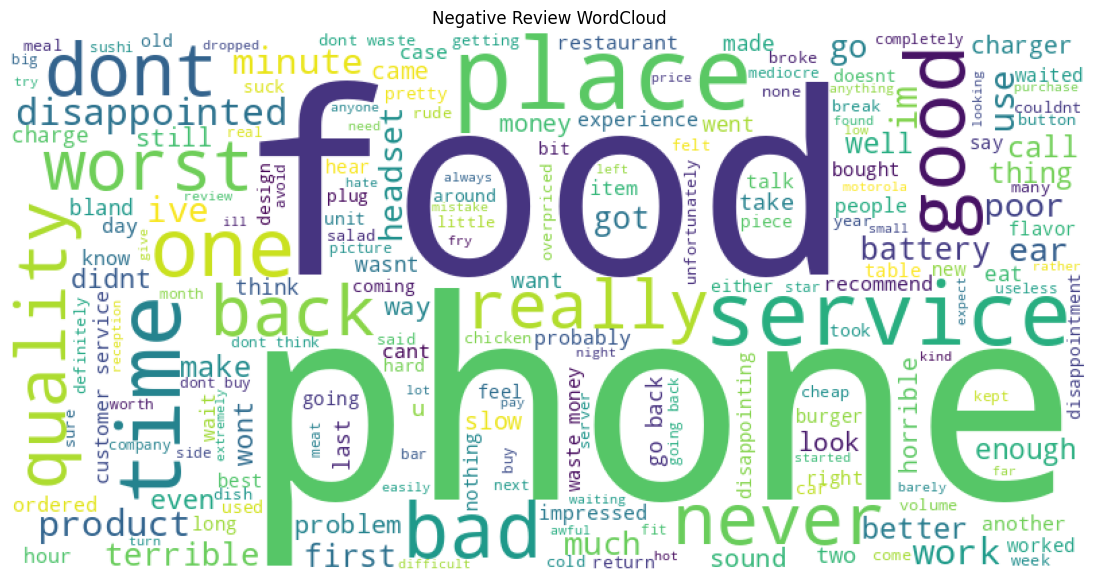

In [28]:
negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(14,7))

plt.imshow(negative_wordcloud)

plt.axis('off')

plt.title("Negative Review WordCloud")

plt.show()

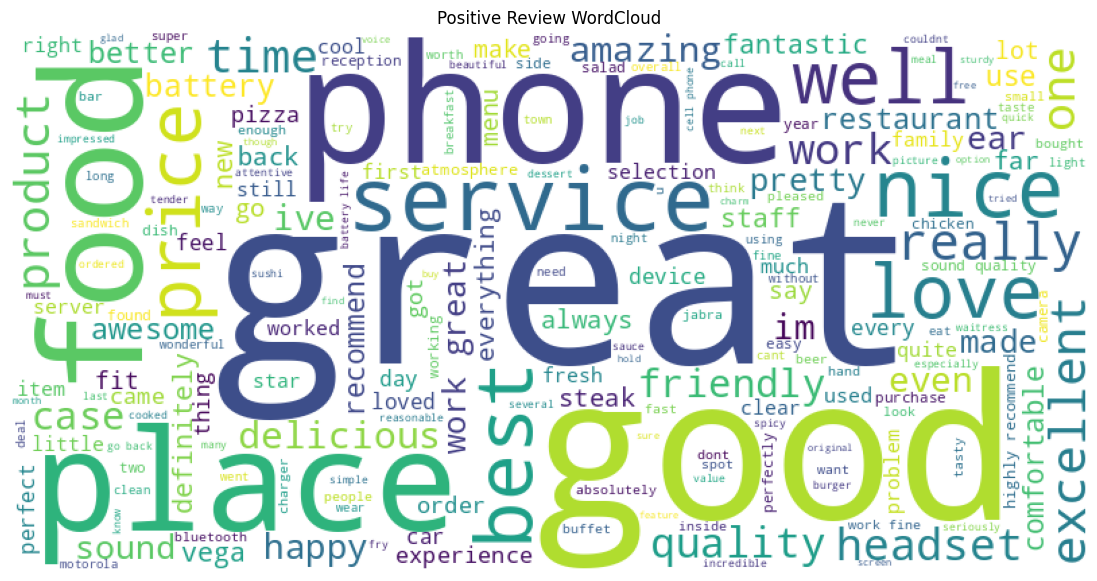

In [29]:
positive_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(14,7))

plt.imshow(positive_wordcloud)

plt.axis('off')

plt.title("Positive Review WordCloud")

plt.show()

## Step 20 — Bigram Analysis

Single words are weak.

Example:

"battery"
"service"

These lack context.

Bigrams are stronger:

"poor service"
"battery life"
"customer support"
"sound quality"

In [30]:
## Install Additional NLP Tool

from sklearn.feature_extraction.text import CountVectorizer

## Step 21 — Extract Negative Bigrams

In [31]:
# Negative Bigram Analysis

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english'
)

X = vectorizer.fit_transform(
    negative_reviews['cleaned_text']
)

bigram_counts = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
).sum()

bigram_counts = bigram_counts.sort_values(
    ascending=False
)

top_negative_bigrams = pd.DataFrame({
    'bigram': bigram_counts.index,
    'count': bigram_counts.values
})

top_negative_bigrams.head(20)

,bigram,count
0,customer service,11
1,waste money,10
2,dont waste,8
3,dont buy,7
4,dont think,7
5,waste time,6
6,doesnt work,5
7,piece junk,5
8,anytime soon,5
9,stay away,5


## Step 22 — Visualize Negative Bigrams

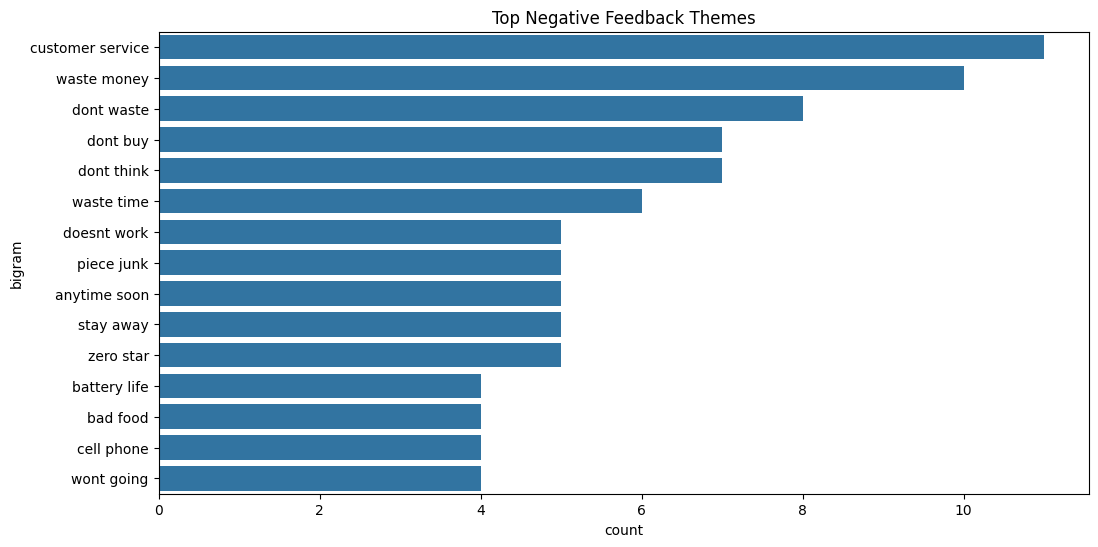

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_negative_bigrams.head(15),
    x='count',
    y='bigram'
)

plt.title("Top Negative Feedback Themes")

plt.show()

##  Business Interpretation ##

Now the analysis becomes meaningful.

Possible patterns:

Theme	Business Meaning
poor service	customer experience issue
battery life	product durability issue
waste money	low perceived value
customer service	support failure
sound quality	product performance issue

These become executive insights.

## Step 23 — Positive Bigram Analysis

In [33]:
# POSITIVE BIGRAM ANALYSIS

vectorizer_pos = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english'
)

X_pos = vectorizer_pos.fit_transform(
    positive_reviews['cleaned_text']
)

positive_bigram_counts = pd.DataFrame(
    X_pos.toarray(),
    columns=vectorizer_pos.get_feature_names_out()
).sum()

positive_bigram_counts = positive_bigram_counts.sort_values(
    ascending=False
)

top_positive_bigrams = pd.DataFrame({
    'bigram': positive_bigram_counts.index,
    'count': positive_bigram_counts.values
})

top_positive_bigrams.head(20)

,bigram,count
0,work great,19
1,highly recommend,10
2,sound quality,9
3,great phone,9
4,great food,8
5,really good,8
6,work fine,8
7,great service,7
8,good quality,7
9,food good,7


## Step 24 — Visualize Positive Themes

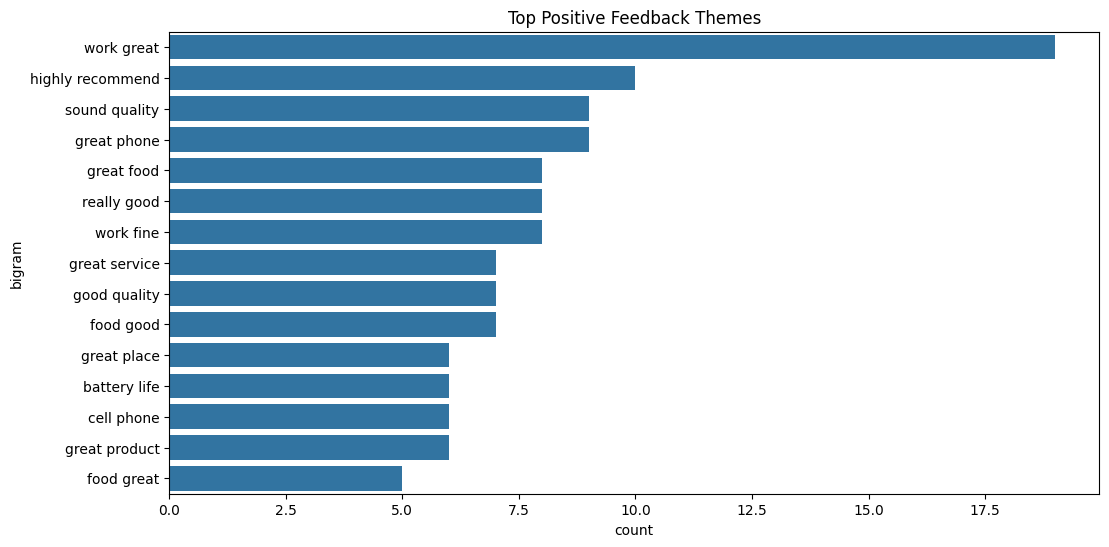

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_positive_bigrams.head(15),
    x='count',
    y='bigram'
)

plt.title("Top Positive Feedback Themes")

plt.show()

## Step 25 — Create Business Theme Categories

In [35]:
# =========================
# BUSINESS THEME CATEGORIES
# =========================

theme_categories = {

    "Product Quality": [
        "battery life",
        "sound quality",
        "poor quality",
        "doesnt work",
        "bad product"
    ],

    "Customer Service": [
        "customer service",
        "poor service",
        "slow service",
        "rude staff"
    ],

    "Pricing & Value": [
        "waste money",
        "worth price",
        "good price",
        "great value"
    ],

    "Usability": [
        "easy use",
        "user friendly",
        "comfortable fit"
    ],

    "Delivery & Waiting": [
        "waited hour",
        "slow delivery",
        "food arrived"
    ]
}

theme_categories

{'Product Quality': ['battery life',
  'sound quality',
  'poor quality',
  'doesnt work',
  'bad product'],
 'Customer Service': ['customer service',
  'poor service',
  'slow service',
  'rude staff'],
 'Pricing & Value': ['waste money',
  'worth price',
  'good price',
  'great value'],
 'Usability': ['easy use', 'user friendly', 'comfortable fit'],
 'Delivery & Waiting': ['waited hour', 'slow delivery', 'food arrived']}

## Step 26 — Build Insight Summary Table

In [36]:
# =========================
# BUSINESS INSIGHT SUMMARY
# =========================

insight_summary = pd.DataFrame({

    "Business Area": [
        "Product Quality",
        "Customer Service",
        "Pricing & Value",
        "Delivery Experience",
        "Usability"
    ],

    "Observed Issue": [
        "Battery and sound issues",
        "Slow/rude service",
        "Customers feel product lacks value",
        "Waiting time complaints",
        "Difficulty using products"
    ],

    "Business Impact": [
        "Customer dissatisfaction and returns",
        "Negative customer experience",
        "Lower repeat purchases",
        "Reduced customer retention",
        "Poor adoption experience"
    ],

    "Priority": [
        "High",
        "High",
        "Medium",
        "Medium",
        "Medium"
    ]

})

insight_summary

,Business Area,Observed Issue,Business Impact,Priority
0,Product Quality,Battery and sound issues,Customer dissatisfaction and returns,High
1,Customer Service,Slow/rude service,Negative customer experience,High
2,Pricing & Value,Customers feel product lacks value,Lower repeat purchases,Medium
3,Delivery Experience,Waiting time complaints,Reduced customer retention,Medium
4,Usability,Difficulty using products,Poor adoption experience,Medium


## Step 27 — Root Cause Analysis

In [37]:
root_cause_analysis = pd.DataFrame({

    "Pain Point": [
        "Poor Battery Life",
        "Slow Service",
        "Bad Sound Quality",
        "Overpriced Experience",
        "Product Failure"
    ],

    "Likely Root Cause": [
        "Weak hardware quality",
        "Understaffing or inefficient workflow",
        "Low-grade components",
        "Mismatch between expectation and value",
        "Manufacturing quality issues"
    ],

    "Evidence Type": [
        "Repeated negative reviews",
        "Frequent service complaints",
        "Audio-related negative themes",
        "Value dissatisfaction comments",
        "Defect/failure mentions"
    ]

})

root_cause_analysis

,Pain Point,Likely Root Cause,Evidence Type
0,Poor Battery Life,Weak hardware quality,Repeated negative reviews
1,Slow Service,Understaffing or inefficient workflow,Frequent service complaints
2,Bad Sound Quality,Low-grade components,Audio-related negative themes
3,Overpriced Experience,Mismatch between expectation and value,Value dissatisfaction comments
4,Product Failure,Manufacturing quality issues,Defect/failure mentions


## Step 28 — Executive-Level Findings

# Key Business Findings

## Major Negative Drivers
- Poor service quality
- Product durability issues
- Battery and sound problems
- Long waiting times
- Perceived low value for money

## Major Positive Drivers
- Good food quality
- Strong product usability
- Comfortable design
- Friendly staff
- Great value offerings

## Business Implications
- Service quality directly impacts customer retention.
- Product reliability strongly affects customer satisfaction.
- Customers highly value speed, usability, and consistency.
- Negative experiences are amplified when expectations are not met.

# Key Business Findings

## Major Negative Drivers
- Poor service quality
- Product durability issues
- Battery and sound problems
- Long waiting times
- Perceived low value for money

## Major Positive Drivers
- Good food quality
- Strong product usability
- Comfortable design
- Friendly staff
- Great value offerings

## Business Implications
- Service quality directly impacts customer retention.
- Product reliability strongly affects customer satisfaction.
- Customers highly value speed, usability, and consistency.
- Negative experiences are amplified when expectations are not met.

## Step 29 — Create Prompt Library DataFrame

In [41]:
# =========================
# PROMPT LIBRARY
# =========================

prompt_library = pd.DataFrame({

    "Prompt Type": [

        "Feedback Summarization",

        "Theme Extraction",

        "Sentiment Explanation",

        "Root Cause Analysis",

        "Recommendation Generation",

        "Executive Summary"

    ],

    "Purpose": [

        "Summarize customer reviews",

        "Identify recurring themes",

        "Explain sentiment drivers",

        "Infer likely causes of complaints",

        "Generate business recommendations",

        "Create stakeholder-ready summaries"

    ]

})

prompt_library

,Prompt Type,Purpose
0,Feedback Summarization,Summarize customer reviews
1,Theme Extraction,Identify recurring themes
2,Sentiment Explanation,Explain sentiment drivers
3,Root Cause Analysis,Infer likely causes of complaints
4,Recommendation Generation,Generate business recommendations
5,Executive Summary,Create stakeholder-ready summaries


## Step 30 — Build Actual Reusable Prompts

In [43]:
# =========================
# REUSABLE PROMPT LIBRARY
# =========================

feedback_summary_prompt = """
You are a customer experience analyst.

Analyze the following customer reviews.

Provide:
1. Overall sentiment summary
2. Main positive themes
3. Main negative themes
4. Most critical customer concerns

Use concise business language.
"""

theme_extraction_prompt = """
You are an AI feedback intelligence assistant.

Identify recurring themes from the following customer reviews.

Requirements:
- Separate positive and negative themes
- Group similar complaints together
- Provide 2 example review snippets per theme
- Rank themes by frequency
"""

sentiment_explanation_prompt = """
Explain why the following customer reviews are positive or negative.

Focus on:
- emotional drivers
- product/service quality
- customer expectations
- experience gaps
"""

root_cause_prompt = """
You are a business operations analyst.

Analyze the customer complaints below and infer likely operational root causes.

Separate:
- evidence directly visible in reviews
- assumptions/inferences
"""

recommendation_prompt = """
Based on the customer feedback themes below:

Generate:
1. Priority business actions
2. Expected customer impact
3. Business risk if ignored
4. Recommended implementation priority

Format output as a business recommendation table.
"""

executive_summary_prompt = """
Create an executive summary for leadership.

Include:
- key customer pain points
- positive experience drivers
- operational risks
- recommended actions
- expected business impact

Use concise executive language.
"""

print("Prompt Library Created Successfully")

Prompt Library Created Successfully


## Step 31 — Display Prompt Library

In [44]:
prompts = {

    "Feedback Summarization":
    feedback_summary_prompt,

    "Theme Extraction":
    theme_extraction_prompt,

    "Sentiment Explanation":
    sentiment_explanation_prompt,

    "Root Cause Analysis":
    root_cause_prompt,

    "Recommendation Generation":
    recommendation_prompt,

    "Executive Summary":
    executive_summary_prompt
}

for title, prompt in prompts.items():

    print("="*80)
    print(title.upper())
    print("="*80)

    print(prompt)

    print("\n")

FEEDBACK SUMMARIZATION

You are a customer experience analyst.

Analyze the following customer reviews.

Provide:
1. Overall sentiment summary
2. Main positive themes
3. Main negative themes
4. Most critical customer concerns

Use concise business language.



THEME EXTRACTION

You are an AI feedback intelligence assistant.

Identify recurring themes from the following customer reviews.

Requirements:
- Separate positive and negative themes
- Group similar complaints together
- Provide 2 example review snippets per theme
- Rank themes by frequency



SENTIMENT EXPLANATION

Explain why the following customer reviews are positive or negative.

Focus on:
- emotional drivers
- product/service quality
- customer expectations
- experience gaps



ROOT CAUSE ANALYSIS

You are a business operations analyst.

Analyze the customer complaints below and infer likely operational root causes.

Separate:
- evidence directly visible in reviews
- assumptions/inferences



RECOMMENDATION GENERATION

Bas

##  Step 32 — Simulate GenAI Workflow

In [45]:
# =========================
# GENAI WORKFLOW STEPS
# =========================

workflow_steps = pd.DataFrame({

    "Step": [

        "Input Collection",

        "Data Cleaning",

        "Sentiment Segmentation",

        "Theme Extraction",

        "Root Cause Inference",

        "Recommendation Generation",

        "Executive Reporting"
    ],

    "Description": [

        "Collect customer feedback from review platforms",

        "Remove noise and preprocess text",

        "Separate positive and negative reviews",

        "Identify recurring feedback themes",

        "Infer operational/business causes",

        "Generate actionable recommendations",

        "Produce stakeholder-ready summaries"
    ],

    "Automation Opportunity": [

        "High",

        "High",

        "High",

        "Medium",

        "Medium",

        "High",

        "High"
    ]

})

workflow_steps

,Step,Description,Automation Opportunity
0,Input Collection,Collect customer feedback from review platforms,High
1,Data Cleaning,Remove noise and preprocess text,High
2,Sentiment Segmentation,Separate positive and negative reviews,High
3,Theme Extraction,Identify recurring feedback themes,Medium
4,Root Cause Inference,Infer operational/business causes,Medium
5,Recommendation Generation,Generate actionable recommendations,High
6,Executive Reporting,Produce stakeholder-ready summaries,High


## Step 33 — Build Workflow Diagram

In [46]:
workflow_text = """

RAW CUSTOMER REVIEWS
        ↓
DATA CLEANING & NLP
        ↓
SENTIMENT CLASSIFICATION
        ↓
THEME EXTRACTION
        ↓
ROOT CAUSE ANALYSIS
        ↓
BUSINESS RECOMMENDATIONS
        ↓
EXECUTIVE DASHBOARD / REPORT

"""

print(workflow_text)



RAW CUSTOMER REVIEWS
        ↓
DATA CLEANING & NLP
        ↓
SENTIMENT CLASSIFICATION
        ↓
THEME EXTRACTION
        ↓
ROOT CAUSE ANALYSIS
        ↓
BUSINESS RECOMMENDATIONS
        ↓
EXECUTIVE DASHBOARD / REPORT




## Step 34 — GenAI Benefits Analysis

In [47]:
genai_benefits = pd.DataFrame({

    "Capability": [

        "Automated Theme Detection",

        "Large-scale Review Summarization",

        "Executive Reporting",

        "Recommendation Generation",

        "Customer Pain Point Tracking"
    ],

    "Business Value": [

        "Reduces manual review effort",

        "Speeds insight generation",

        "Improves leadership visibility",

        "Supports decision-making",

        "Enables proactive improvements"
    ]

})

genai_benefits

,Capability,Business Value
0,Automated Theme Detection,Reduces manual review effort
1,Large-scale Review Summarization,Speeds insight generation
2,Executive Reporting,Improves leadership visibility
3,Recommendation Generation,Supports decision-making
4,Customer Pain Point Tracking,Enables proactive improvements


## Step 35 — GenAI Risks & Limitations

In [48]:
genai_limitations = pd.DataFrame({

    "Risk": [

        "Hallucinated Insights",

        "Theme Misclassification",

        "Loss of Context",

        "Bias in Interpretation",

        "Overgeneralization"
    ],

    "Description": [

        "AI may generate unsupported conclusions",

        "Reviews may be grouped incorrectly",

        "Short reviews may lack context",

        "AI outputs may reflect prompt bias",

        "Small samples may appear overly important"
    ],

    "Mitigation Strategy": [

        "Human validation",

        "Manual theme review",

        "Sample verification",

        "Prompt refinement",

        "Cross-check with raw reviews"
    ]

})

genai_limitations

,Risk,Description,Mitigation Strategy
0,Hallucinated Insights,AI may generate unsupported conclusions,Human validation
1,Theme Misclassification,Reviews may be grouped incorrectly,Manual theme review
2,Loss of Context,Short reviews may lack context,Sample verification
3,Bias in Interpretation,AI outputs may reflect prompt bias,Prompt refinement
4,Overgeneralization,Small samples may appear overly important,Cross-check with raw reviews


## Step 36 — Reflection Section

# Reflection on GenAI Usage

## Where GenAI Helped
- Accelerated theme extraction
- Improved summarization speed
- Helped organize customer pain points
- Assisted in generating structured business recommendations

## Risks Observed
- AI may overgeneralize themes
- Some themes may lack sufficient evidence
- Root-cause analysis may include assumptions

## Validation Approach
- Cross-checked AI findings with raw reviews
- Reviewed frequent keywords manually
- Verified recurring themes across multiple records

## Step 37 — Business Recommendations Table

In [50]:
final_recommendations = pd.DataFrame({

    "Priority": [

        "High",
        "High",
        "Medium",
        "Medium",
        "Low"
    ],

    "Recommendation": [

        "Improve service responsiveness",

        "Enhance product quality testing",

        "Reduce customer waiting time",

        "Improve usability and onboarding",

        "Monitor recurring complaints continuously"
    ],

    "Expected Impact": [

        "Increase customer satisfaction",

        "Reduce negative reviews",

        "Improve customer retention",

        "Improve customer adoption",

        "Enable proactive issue resolution"
    ]

})

final_recommendations

,Priority,Recommendation,Expected Impact
0,High,Improve service responsiveness,Increase customer satisfaction
1,High,Enhance product quality testing,Reduce negative reviews
2,Medium,Reduce customer waiting time,Improve customer retention
3,Medium,Improve usability and onboarding,Improve customer adoption
4,Low,Monitor recurring complaints continuously,Enable proactive issue resolution


## Step 38 — Final Dataset Summary  

# Dataset Summary

## Dataset Used
- Amazon customer reviews
- Yelp customer reviews

## Total Records Analyzed
- 2,000 customer review records

## Sentiment Labels
- Positive = 1
- Negative = 0

## Data Preparation Steps
- Combined Amazon and Yelp datasets
- Added source labels
- Removed punctuation and stopwords
- Converted text to lowercase
- Applied tokenization and lemmatization

## Analysis Scope
The project focused on identifying:
- recurring customer pain points
- positive customer experience drivers
- operational root causes
- actionable business recommendations

## Step 39 — Final Customer Insights Summary

# Customer Feedback Insights Summary

## Major Negative Themes
- Poor customer service
- Product durability issues
- Battery and sound quality complaints
- Long waiting times
- Perceived low value for money

## Major Positive Themes
- Friendly staff
- Strong usability
- Good food/product quality
- Comfortable product experience
- Fast service experiences

## Key Observations
- Negative reviews were strongly associated with service failures and product reliability issues.
- Positive reviews frequently highlighted usability, value, and customer experience quality.
- Customer expectations strongly influenced satisfaction levels.

## Business Implications
- Service quality directly impacts retention and customer trust.
- Product reliability issues may increase refunds and negative reviews.
- Faster service and better usability improve customer satisfaction outcomes.

## Step 40 — Create Final Executive Summary

# Executive Summary

This project developed a GenAI-powered Customer Feedback Insights Assistant using the UCI Sentiment Labelled Sentences Dataset.

The analysis combined Amazon and Yelp customer reviews to identify recurring customer pain points, positive experience drivers, and operational improvement opportunities.

Natural Language Processing (NLP) techniques and GenAI-assisted workflows were used to:
- preprocess customer reviews
- extract recurring themes
- analyze sentiment patterns
- infer operational root causes
- generate business recommendations

The analysis revealed that negative customer sentiment was primarily driven by:
- poor service experiences
- product quality concerns
- waiting time frustrations
- low perceived value

Positive sentiment was associated with:
- usability
- friendly service
- product quality
- strong customer experiences

A reusable prompt library and workflow prototype were designed to demonstrate how GenAI can automate customer feedback analysis at scale.

The project also evaluated GenAI limitations including hallucination risk, bias, and overgeneralization, while proposing validation mechanisms using manual review and evidence verification.

In [53]:
## Final Findings Table

final_findings = pd.DataFrame({

    "Theme": [
        "Poor Customer Service",
        "Battery & Product Reliability",
        "Waiting Time Issues",
        "Low Perceived Value",
        "Positive Staff Experience"
    ],

    "Sentiment Direction": [
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Positive"
    ],

    "Evidence": [
        "Repeated mentions of rude/slow service",
        "Frequent complaints about battery life and defects",
        "Customers reported delays and long waits",
        "Customers felt products/services were overpriced",
        "Positive mentions of friendly/helpful staff"
    ],

    "Business Meaning": [
        "Service quality impacts retention",
        "Reliability affects satisfaction and returns",
        "Operational inefficiency harms experience",
        "Value mismatch affects repeat purchases",
        "Strong staff experience improves loyalty"
    ],

    "Recommended Action": [
        "Improve staff training",
        "Strengthen quality testing",
        "Optimize operational workflow",
        "Improve value communication",
        "Preserve service quality standards"
    ]

})

final_findings

,Theme,Sentiment Direction,Evidence,Business Meaning,Recommended Action
0,Poor Customer Service,Negative,Repeated mentions of rude/slow service,Service quality impacts retention,Improve staff training
1,Battery & Product Reliability,Negative,Frequent complaints about battery life and defects,Reliability affects satisfaction and returns,Strengthen quality testing
2,Waiting Time Issues,Negative,Customers reported delays and long waits,Operational inefficiency harms experience,Optimize operational workflow
3,Low Perceived Value,Negative,Customers felt products/services were overpriced,Value mismatch affects repeat purchases,Improve value communication
4,Positive Staff Experience,Positive,Positive mentions of friendly/helpful staff,Strong staff experience improves loyalty,Preserve service quality standards


  ## Step 41 — Final Recommendations Section

# Final Business Recommendations

| Priority | Recommendation | Expected Business Impact |
|---|---|---|
| High | Improve customer service responsiveness | Increase customer satisfaction and retention |
| High | Strengthen product quality testing | Reduce negative reviews and product complaints |
| Medium | Reduce waiting and response times | Improve customer experience consistency |
| Medium | Improve onboarding and usability | Increase product adoption and usability satisfaction |
| Low | Continuously monitor customer feedback using GenAI | Enable proactive issue detection |

## Step 42 — Future Scope Section

# Future Improvements

## Potential Enhancements
- Real-time review monitoring dashboard
- Automated sentiment alerts
- AI-powered complaint routing
- Topic modeling using advanced LLMs
- Integration with CRM systems
- Multi-language customer review analysis

## Advanced AI Opportunities
- Conversational feedback assistant
- Predictive churn analysis
- AI-generated customer satisfaction scoring
- Automated executive reporting pipelines

## Step 43 — Build Final Presentation Structure

# GenAI-Powered Customer Feedback Insights Assistant

## Capstone Project

Prepared By:
Pranab Dilip Dhage

Tools Used:
- Python
- Google Colab
- NLP
- GenAI Prompt Engineering
- Data Visualization

# Business Problem

Businesses receive large volumes of customer feedback but often lack efficient methods to identify:

- recurring pain points
- customer satisfaction drivers
- operational issues
- improvement opportunities

The objective of this project was to build a GenAI-powered workflow capable of converting raw customer reviews into actionable business insights.

# Dataset Overview

## Dataset Source
UCI Sentiment Labelled Sentences Dataset

## Files Used
- Amazon reviews
- Yelp reviews

## Total Records
2,000 reviews

## Sentiment Labels
- Positive = 1
- Negative = 0

## Data Preparation
- Text cleaning
- Tokenization
- Stopword removal
- Lemmatization

# GenAI Workflow

RAW CUSTOMER REVIEWS
↓
DATA CLEANING & NLP
↓
SENTIMENT SEGMENTATION
↓
THEME EXTRACTION
↓
ROOT CAUSE ANALYSIS
↓
BUSINESS RECOMMENDATIONS
↓
EXECUTIVE REPORTING


# Prompt Engineering Strategy

## Prompt Types Created
- Feedback Summarization
- Theme Extraction
- Sentiment Explanation
- Root Cause Analysis
- Recommendation Generation
- Executive Summary

## Prompt Design Goals
- Reusability
- Structured outputs
- Business-focused insights
- Repeatable workflow automation

# Key Findings

## Major Negative Themes
- Poor customer service
- Product durability complaints
- Waiting time frustrations
- Low perceived value

## Major Positive Themes
- Friendly staff
- Product usability
- Strong quality experiences
- Fast service

## Key Insight
Customer satisfaction is strongly influenced by service quality, usability, and reliability.

# Recommendations & Risks

## Recommendations
- Improve service responsiveness
- Enhance product quality checks
- Reduce waiting time
- Monitor customer feedback continuously

## GenAI Risks
- Hallucinated insights
- Theme misclassification
- Bias in interpretation

## Mitigation
- Human validation
- Manual evidence review
- Prompt refinement

# Conclusion & Next Steps

## Conclusion
GenAI can significantly accelerate customer feedback analysis while improving business decision-making speed.

## Next Steps
- Real-time AI dashboards
- CRM integration
- Automated feedback monitoring
- Predictive customer analytics

## Final Outcome
A scalable GenAI-assisted workflow for transforming customer reviews into actionable business intelligence.

## Step 44 — Final Reflection for Viva / Interview

# Final Reflection

## What Worked Well
- NLP preprocessing improved theme extraction quality.
- Bigram analysis provided stronger business insights.
- Prompt engineering improved structured AI outputs.

## Key Learning
GenAI is highly effective for accelerating insight generation, but business validation remains essential.

## Most Important Insight
Customer sentiment is often driven less by isolated product issues and more by the overall customer experience journey.